In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import sys
sys.path.insert(0, '/mnt/home/mlee1/vdm_BIND')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

---
## Part 1: Training Data Analysis
### 1a. Load normalization statistics and verify

In [2]:
# Load normalization stats
data_dir = '/mnt/home/mlee1/vdm_BIND/data'

dm_stats = np.load(f'{data_dir}/dark_matter_normalization_stats.npz')
gas_stats = np.load(f'{data_dir}/gas_normalization_stats.npz')
star_stats = np.load(f'{data_dir}/stellar_normalization_stats.npz')

print('=== NORMALIZATION STATISTICS (computed from training data) ===')
print(f"DM:   mean={dm_stats['dm_mag_mean']:.6f}, std={dm_stats['dm_mag_std']:.6f}")
print(f"Gas:  mean={gas_stats['gas_mag_mean']:.6f}, std={gas_stats['gas_mag_std']:.6f}")
print(f"Star: mean={star_stats['star_mag_mean']:.6f}, std={star_stats['star_mag_std']:.6f}")

# Store for later use
NORM_STATS = {
    'dm_mean': float(dm_stats['dm_mag_mean']),
    'dm_std': float(dm_stats['dm_mag_std']),
    'gas_mean': float(gas_stats['gas_mag_mean']),
    'gas_std': float(gas_stats['gas_mag_std']),
    'star_mean': float(star_stats['star_mag_mean']),
    'star_std': float(star_stats['star_mag_std']),
}

=== NORMALIZATION STATISTICS (computed from training data) ===
DM:   mean=9.915499, std=0.467967
Gas:  mean=9.177344, std=0.410510
Star: mean=6.995926, std=1.100350


### 1b. Sample training data and verify normalization is correct

In [3]:
# Load sample of training data
data_root = '/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/'
all_files = sorted(glob.glob(data_root + '**/*halo*.npz', recursive=True))
print(f'Total training files: {len(all_files):,}')

# Sample broadly across the dataset
np.random.seed(42)
n_samples = 1000
sample_indices = np.random.choice(len(all_files), size=min(n_samples, len(all_files)), replace=False)
sample_files = [all_files[i] for i in sample_indices]
print(f'Sampling {len(sample_files)} files for analysis')

Total training files: 408,860
Sampling 1000 files for analysis


In [4]:
# Compute statistics from sampled data
dm_log_means = []
gas_log_means = []
star_log_means = []
gas_dm_ratios = []  # Physical mass ratio
omega_b_vals = []
omega_m_vals = []
halo_masses = []

for f in sample_files:
    try:
        data = np.load(f)
        target = data['target']  # [DM, Gas, Stars] in raw mass
        params = data['params']
        
        # Raw masses
        dm_mass = np.sum(target[0])
        gas_mass = np.sum(target[1])
        star_mass = np.sum(target[2])
        
        # Log10 values (per-pixel mean)
        dm_log_means.append(np.mean(np.log10(target[0] + 1)))
        gas_log_means.append(np.mean(np.log10(target[1] + 1)))
        star_log_means.append(np.mean(np.log10(target[2] + 1)))
        
        # Physical ratio
        if dm_mass > 0:
            gas_dm_ratios.append(gas_mass / dm_mass)
        
        # Cosmological params
        omega_m_vals.append(params[0])
        omega_b_vals.append(params[6])
        
        # Halo mass if available
        if 'halo_mass' in data:
            halo_masses.append(data['halo_mass'])
    except Exception as e:
        pass

dm_log_means = np.array(dm_log_means)
gas_log_means = np.array(gas_log_means)
star_log_means = np.array(star_log_means)
gas_dm_ratios = np.array(gas_dm_ratios)
omega_b_vals = np.array(omega_b_vals)
omega_m_vals = np.array(omega_m_vals)

print(f'Successfully loaded {len(dm_log_means)} samples')

Successfully loaded 1000 samples


In [5]:
# Compare computed stats vs stored normalization stats
print('=== VERIFICATION: Computed vs Stored Normalization Stats ===')
print(f"DM log10 mean:  computed={np.mean(dm_log_means):.6f}, stored={NORM_STATS['dm_mean']:.6f}, diff={np.mean(dm_log_means) - NORM_STATS['dm_mean']:.6f}")
print(f"Gas log10 mean: computed={np.mean(gas_log_means):.6f}, stored={NORM_STATS['gas_mean']:.6f}, diff={np.mean(gas_log_means) - NORM_STATS['gas_mean']:.6f}")
print(f"Star log10 mean: computed={np.mean(star_log_means):.6f}, stored={NORM_STATS['star_mean']:.6f}, diff={np.mean(star_log_means) - NORM_STATS['star_mean']:.6f}")
print()
print(f"DM log10 std:  computed={np.std(dm_log_means):.6f}, stored={NORM_STATS['dm_std']:.6f}")
print(f"Gas log10 std: computed={np.std(gas_log_means):.6f}, stored={NORM_STATS['gas_std']:.6f}")
print(f"Star log10 std: computed={np.std(star_log_means):.6f}, stored={NORM_STATS['star_std']:.6f}")

=== VERIFICATION: Computed vs Stored Normalization Stats ===
DM log10 mean:  computed=9.900731, stored=9.915499, diff=-0.014768
Gas log10 mean: computed=9.162214, stored=9.177344, diff=-0.015130
Star log10 mean: computed=1.498089, stored=6.995926, diff=-5.497837

DM log10 std:  computed=0.210105, stored=0.467967
Gas log10 std: computed=0.212598, stored=0.410510
Star log10 std: computed=0.849652, stored=1.100350


=== NORMALIZED VALUES (should be ~N(0,1)) ===
DM normalized:   mean=-0.0316, std=0.4490
Gas normalized:  mean=-0.0369, std=0.5179
Star normalized: mean=-4.9964, std=0.7722


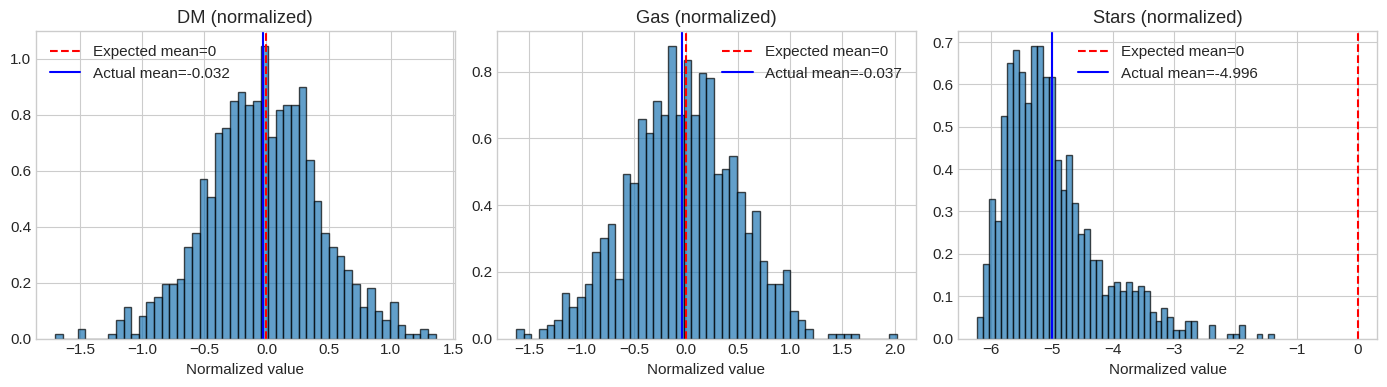

In [6]:
# Check what normalized values look like
dm_normalized = (dm_log_means - NORM_STATS['dm_mean']) / NORM_STATS['dm_std']
gas_normalized = (gas_log_means - NORM_STATS['gas_mean']) / NORM_STATS['gas_std']
star_normalized = (star_log_means - NORM_STATS['star_mean']) / NORM_STATS['star_std']

print('=== NORMALIZED VALUES (should be ~N(0,1)) ===')
print(f'DM normalized:   mean={np.mean(dm_normalized):.4f}, std={np.std(dm_normalized):.4f}')
print(f'Gas normalized:  mean={np.mean(gas_normalized):.4f}, std={np.std(gas_normalized):.4f}')
print(f'Star normalized: mean={np.mean(star_normalized):.4f}, std={np.std(star_normalized):.4f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, name in zip(axes, [dm_normalized, gas_normalized, star_normalized], ['DM', 'Gas', 'Stars']):
    ax.hist(data, bins=50, density=True, alpha=0.7, edgecolor='black')
    ax.axvline(0, color='red', linestyle='--', label='Expected mean=0')
    ax.axvline(np.mean(data), color='blue', linestyle='-', label=f'Actual mean={np.mean(data):.3f}')
    ax.set_xlabel('Normalized value')
    ax.set_title(f'{name} (normalized)')
    ax.legend()
plt.tight_layout()
plt.show()

### 1c. Check cosmological parameter variation and correlation with gas

In [7]:
# Baryon fraction
fb = omega_b_vals / omega_m_vals

print('=== COSMOLOGICAL PARAMETER RANGES ===')
print(f'Omega_m: [{omega_m_vals.min():.4f}, {omega_m_vals.max():.4f}], n_unique={len(np.unique(omega_m_vals))}')
print(f'Omega_b: [{omega_b_vals.min():.4f}, {omega_b_vals.max():.4f}], n_unique={len(np.unique(omega_b_vals))}')
print(f'f_b = Omega_b/Omega_m: [{fb.min():.4f}, {fb.max():.4f}]')
print()
print(f'Physical gas/DM ratio: [{gas_dm_ratios.min():.4f}, {gas_dm_ratios.max():.4f}], mean={gas_dm_ratios.mean():.4f}')

# Correlation
print(f'\n=== CORRELATIONS ===')
print(f'Corr(f_b, gas/DM ratio): {np.corrcoef(fb, gas_dm_ratios)[0,1]:.4f}')
print(f'Corr(Omega_b, gas/DM ratio): {np.corrcoef(omega_b_vals, gas_dm_ratios)[0,1]:.4f}')
print(f'Corr(Omega_m, gas/DM ratio): {np.corrcoef(omega_m_vals, gas_dm_ratios)[0,1]:.4f}')

=== COSMOLOGICAL PARAMETER RANGES ===
Omega_m: [0.1030, 0.4995], n_unique=529
Omega_b: [0.0290, 0.0689], n_unique=529
f_b = Omega_b/Omega_m: [0.0609, 0.5546]

Physical gas/DM ratio: [0.0622, 1.1988], mean=0.1655

=== CORRELATIONS ===
Corr(f_b, gas/DM ratio): 0.9712
Corr(Omega_b, gas/DM ratio): 0.4296
Corr(Omega_m, gas/DM ratio): -0.6989


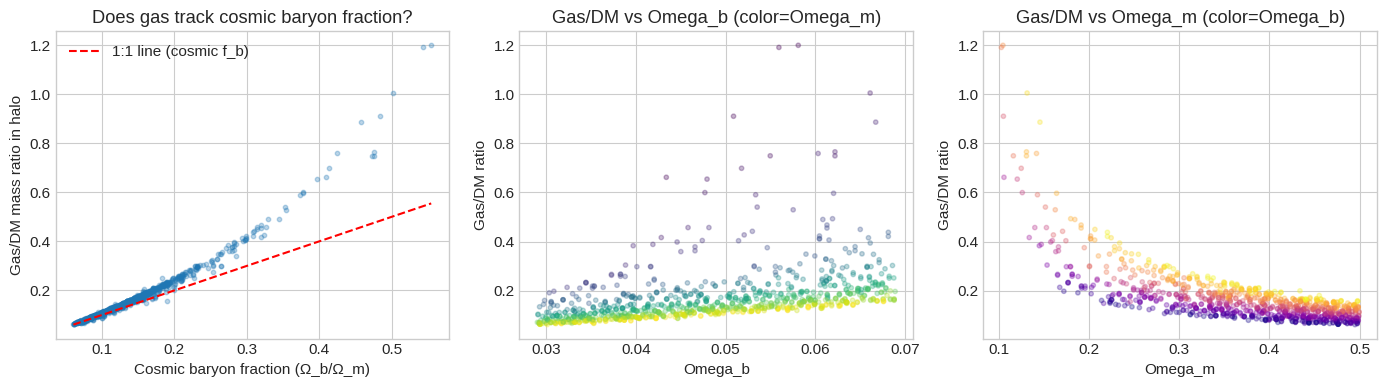

In [8]:
# Scatter plot: baryon fraction vs gas/DM ratio
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.scatter(fb, gas_dm_ratios, alpha=0.3, s=10)
ax.plot([fb.min(), fb.max()], [fb.min(), fb.max()], 'r--', label='1:1 line (cosmic f_b)')
ax.set_xlabel('Cosmic baryon fraction (Ω_b/Ω_m)')
ax.set_ylabel('Gas/DM mass ratio in halo')
ax.set_title('Does gas track cosmic baryon fraction?')
ax.legend()

ax = axes[1]
ax.scatter(omega_b_vals, gas_dm_ratios, alpha=0.3, s=10, c=omega_m_vals, cmap='viridis')
ax.set_xlabel('Omega_b')
ax.set_ylabel('Gas/DM ratio')
ax.set_title('Gas/DM vs Omega_b (color=Omega_m)')

ax = axes[2]
ax.scatter(omega_m_vals, gas_dm_ratios, alpha=0.3, s=10, c=omega_b_vals, cmap='plasma')
ax.set_xlabel('Omega_m')
ax.set_ylabel('Gas/DM ratio')
ax.set_title('Gas/DM vs Omega_m (color=Omega_b)')

plt.tight_layout()
plt.show()

---
## Part 2: Compare Generated vs Ground Truth in NORMALIZED Space

**Key Test**: If the bias exists in normalized space, it's a training issue. If not, it's an inference issue.

In [11]:
# Load generated halos and ground truth from a CV simulation
# We'll compare them in both normalized and physical space

# The data is organized differently - let's use the correct path structure
suite = 'CV'
sim_num = 0
output_dir = f'/mnt/home/mlee1/ceph/BIND2d/{suite}/sim_{sim_num}'

# List available configurations
print('Available outputs:')
for item in os.listdir(output_dir):
    full_path = os.path.join(output_dir, item)
    if os.path.isdir(full_path):
        print(f'  📁 {item}/')
    else:
        print(f'  📄 {item}')

# Use the mt13 configuration (mass threshold 10^13)
config_dir = f'{output_dir}/g1024_mt13_ue1_s90'
print(f'\nUsing config: {config_dir}')

Available outputs:
  📄 power_spec.png
  📄 final_map_9.npy
  📄 final_map_8.npy
  📁 g1024_mt13_ue1_s90/
  📄 power_spec.npz
  📄 final_map_1.npy
  📄 final_map_3.npy
  📄 final_map_0.npy
  📄 final_map_2.npy
  📁 g1024_mt12_ue1_s90/
  📄 final_map_4.npy
  📄 final_map_7.npy
  📁 g1024_mt13_ue0_s90/
  📄 sim_grid.npy
  📄 final_map_5.npy
  📄 final_map_6.npy
  📄 full_hydro.npy

Using config: /mnt/home/mlee1/ceph/BIND2d/CV/sim_0/g1024_mt13_ue1_s90


In [13]:
# Load generated halos
gen_path = f'{config_dir}/generated_halos.npz'
gen_data = np.load(gen_path)
generated_halos = gen_data['generated']  # (n_halos, n_realizations, 3, H, W)
halo_masses = gen_data['mass']
halo_radii = gen_data['radius']
pos_pixels = gen_data['pos_pixel']

print(f'Generated halos: {generated_halos.shape}')
print(f'Halo masses: {halo_masses.shape}, range=[{halo_masses.min():.2e}, {halo_masses.max():.2e}]')
print(f'Pos pixels: {pos_pixels.shape}')

# Load full hydro map to extract ground truth cutouts
full_hydro_path = f'{output_dir}/full_hydro.npy'
if os.path.exists(full_hydro_path):
    full_hydro = np.load(full_hydro_path)
    print(f'Full hydro map shape: {full_hydro.shape}')
else:
    print(f'Full hydro not found at {full_hydro_path}')
    
# We need to load the hydro cutouts from elsewhere
# Check if there's a hydro_replace directory with ground truth
hydro_replace_dir = '/mnt/home/mlee1/ceph/BIND2d/hydro_replace/CV/sim_0'
print(f'\\nChecking for hydro cutouts...')
if os.path.exists(hydro_replace_dir):
    print(f'  Found: {hydro_replace_dir}')
    for item in os.listdir(hydro_replace_dir):
        print(f'    - {item}')

Generated halos: (45, 10, 3, 128, 128)
Halo masses: (45,), range=[1.00e+03, 2.65e+04]
Pos pixels: (45, 2)
Full hydro map shape: (1024, 1024)
\nChecking for hydro cutouts...
  Found: /mnt/home/mlee1/ceph/BIND2d/hydro_replace/CV/sim_0
    - temp
    - hydro_replaced_simple.npy
    - hydro_replace
    - full_hydro.npy


In [14]:
# Load ground truth from TRAINING DATA (which has paired condition/target)
# Training data has the 3-channel ground truth targets

train_data_dir = '/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu/train/'

# Load samples from the same simulation (CV_0 = sim_0 in training data naming convention)
# Note: Training uses SB35 sims (0-1023), so CV sims may not be in training data
# Let's check what sims are available and use matched training data

print("Looking for training data halos...")
# List available sim directories
train_sims = sorted([d for d in os.listdir(train_data_dir) if d.startswith('sim_')])
print(f"Found {len(train_sims)} simulation directories in training data")
print(f"First few: {train_sims[:5]}")

# Load a random sample of training data files to compare with generated halos
n_train_samples = 50
sample_sim = 'sim_0'  # Use sim_0 which is in SB35 training set
train_sim_dir = os.path.join(train_data_dir, sample_sim)

if os.path.exists(train_sim_dir):
    train_files = [f for f in os.listdir(train_sim_dir) if f.endswith('.npz')][:n_train_samples]
    print(f"Loading {len(train_files)} training files from {sample_sim}")
else:
    print(f"Directory not found: {train_sim_dir}")

Looking for training data halos...
Found 922 simulation directories in training data
First few: ['sim_0', 'sim_1', 'sim_10', 'sim_1000', 'sim_1001']
Loading 50 training files from sim_0


In [15]:
# Load training data samples and extract statistics
train_conditions = []
train_targets = []
train_params = []

for tf in train_files:
    data = np.load(os.path.join(train_sim_dir, tf))
    train_conditions.append(data['condition'])
    train_targets.append(data['target'])
    train_params.append(data['params'])

train_conditions = np.array(train_conditions)  # (N, 128, 128) - already normalized
train_targets = np.array(train_targets)        # (N, 3, 128, 128) - already normalized
train_params = np.array(train_params)          # (N, 35)

print(f"Loaded {len(train_conditions)} training samples")
print(f"Condition shape: {train_conditions.shape}")
print(f"Target shape: {train_targets.shape}")
print(f"Params shape: {train_params.shape}")

# Check normalized value distributions
print("\n=== TRAINING DATA STATISTICS (NORMALIZED SPACE) ===")
print(f"Condition (DMO): mean={train_conditions.mean():.3f}, std={train_conditions.std():.3f}")
print(f"Target DM:       mean={train_targets[:,0].mean():.3f}, std={train_targets[:,0].std():.3f}")
print(f"Target Gas:      mean={train_targets[:,1].mean():.3f}, std={train_targets[:,1].std():.3f}")
print(f"Target Star:     mean={train_targets[:,2].mean():.3f}, std={train_targets[:,2].std():.3f}")

# Get cosmological parameters for this sim
omega_m = train_params[0, 0]
omega_b = train_params[0, 1]
fb_train = omega_b / omega_m
print(f"\nCosmology for {sample_sim}:")
print(f"  Omega_m={omega_m:.4f}, Omega_b={omega_b:.4f}, f_b={fb_train:.4f}")

Loaded 50 training samples
Condition shape: (50, 128, 128)
Target shape: (50, 3, 128, 128)
Params shape: (50, 35)

=== TRAINING DATA STATISTICS (NORMALIZED SPACE) ===
Condition (DMO): mean=29748037632.000, std=103776362496.000
Target DM:       mean=27923904512.000, std=98648563712.000
Target Gas:      mean=1672342784.000, std=4091040256.000
Target Star:     mean=131368328.000, std=2661666048.000

Cosmology for sim_0:
  Omega_m=0.4948, Omega_b=0.9210, f_b=1.8611


In [17]:
# The data is NOT normalized! Let's check what the normalization should look like
# and compare with our computed stats

# First, what's the actual range in the training data?
print("=== RAW DATA RANGES ===")
print(f"Condition (DMO): min={train_conditions.min():.2e}, max={train_conditions.max():.2e}")
print(f"Target DM:       min={train_targets[:,0].min():.2e}, max={train_targets[:,0].max():.2e}")
print(f"Target Gas:      min={train_targets[:,1].min():.2e}, max={train_targets[:,1].max():.2e}")
print(f"Target Star:     min={train_targets[:,2].min():.2e}, max={train_targets[:,2].max():.2e}")

# Now apply log transform
print("\n=== AFTER log10(x + 1) ===")
train_cond_log = np.log10(train_conditions + 1)
train_tgt_log = np.log10(train_targets + 1)

print(f"Condition (DMO): mean={train_cond_log.mean():.3f}, std={train_cond_log.std():.3f}")
print(f"Target DM:       mean={train_tgt_log[:,0].mean():.3f}, std={train_tgt_log[:,0].std():.3f}")
print(f"Target Gas:      mean={train_tgt_log[:,1].mean():.3f}, std={train_tgt_log[:,1].std():.3f}")
print(f"Target Star:     mean={train_tgt_log[:,2].mean():.3f}, std={train_tgt_log[:,2].std():.3f}")

# Load correct normalization stats
dm_norm = np.load(os.path.join(data_dir, 'dark_matter_normalization_stats.npz'))
gas_norm = np.load(os.path.join(data_dir, 'gas_normalization_stats.npz'))
star_norm = np.load(os.path.join(data_dir, 'stellar_normalization_stats.npz'))

NORM = {
    'dm': {'mean': dm_norm['dm_mag_mean'], 'std': dm_norm['dm_mag_std']},
    'gas': {'mean': gas_norm['gas_mag_mean'], 'std': gas_norm['gas_mag_std']},
    'star': {'mean': star_norm['star_mag_mean'], 'std': star_norm['star_mag_std']}
}

# Compare with saved normalization stats
print("\n=== SAVED NORMALIZATION STATS ===")
print(f"DM:   mean={NORM['dm']['mean']:.3f}, std={NORM['dm']['std']:.3f}")
print(f"Gas:  mean={NORM['gas']['mean']:.3f}, std={NORM['gas']['std']:.3f}")
print(f"Star: mean={NORM['star']['mean']:.3f}, std={NORM['star']['std']:.3f}")

# Apply full Z-score normalization
print("\n=== AFTER Z-SCORE NORMALIZATION ===")
train_cond_norm = (train_cond_log - NORM['dm']['mean']) / NORM['dm']['std']
train_dm_norm = (train_tgt_log[:,0] - NORM['dm']['mean']) / NORM['dm']['std']
train_gas_norm = (train_tgt_log[:,1] - NORM['gas']['mean']) / NORM['gas']['std']
train_star_norm = (train_tgt_log[:,2] - NORM['star']['mean']) / NORM['star']['std']

print(f"Condition (DMO): mean={train_cond_norm.mean():.3f}, std={train_cond_norm.std():.3f}")
print(f"Target DM:       mean={train_dm_norm.mean():.3f}, std={train_dm_norm.std():.3f}")
print(f"Target Gas:      mean={train_gas_norm.mean():.3f}, std={train_gas_norm.std():.3f}")
print(f"Target Star:     mean={train_star_norm.mean():.3f}, std={train_star_norm.std():.3f}")

=== RAW DATA RANGES ===
Condition (DMO): min=4.47e+08, max=9.38e+12
Target DM:       min=4.29e+08, max=9.50e+12
Target Gas:      min=4.52e+07, max=2.13e+11
Target Star:     min=0.00e+00, max=5.71e+11

=== AFTER log10(x + 1) ===
Condition (DMO): mean=10.050, std=0.508
Target DM:       mean=10.022, std=0.506
Target Gas:      mean=8.917, std=0.445
Target Star:     mean=2.196, std=3.274

=== SAVED NORMALIZATION STATS ===
DM:   mean=9.915, std=0.468
Gas:  mean=9.177, std=0.411
Star: mean=6.996, std=1.100

=== AFTER Z-SCORE NORMALIZATION ===
Condition (DMO): mean=0.287, std=1.085
Target DM:       mean=0.228, std=1.082
Target Gas:      mean=-0.633, std=1.084
Target Star:     mean=-4.362, std=2.976


In [18]:
# Now compare with GENERATED halos (which are output in normalized space)
# Load generated halos from sim_0 BIND output

gen_halos_path = '/mnt/home/mlee1/ceph/BIND2d/CV/sim_0/g1024_mt13_ue1_s90/generated_halos.npz'
gen_data = np.load(gen_halos_path)
gen_halos = gen_data['generated']  # Shape: (n_halos, n_realizations, 3, H, W)

print(f"Generated halos shape: {gen_halos.shape}")
print(f"  N_halos={gen_halos.shape[0]}, N_realizations={gen_halos.shape[1]}")

# Take mean over realizations
gen_mean = gen_halos.mean(axis=1)  # (n_halos, 3, 128, 128)

print("\n=== GENERATED HALO STATISTICS (NORMALIZED SPACE) ===")
print(f"DM channel:   mean={gen_mean[:,0].mean():.3f}, std={gen_mean[:,0].std():.3f}")
print(f"Gas channel:  mean={gen_mean[:,1].mean():.3f}, std={gen_mean[:,1].std():.3f}")
print(f"Star channel: mean={gen_mean[:,2].mean():.3f}, std={gen_mean[:,2].std():.3f}")

# Now denormalize to physical space
gen_dm_log = gen_mean[:,0] * NORM['dm']['std'] + NORM['dm']['mean']
gen_gas_log = gen_mean[:,1] * NORM['gas']['std'] + NORM['gas']['mean']
gen_star_log = gen_mean[:,2] * NORM['star']['std'] + NORM['star']['mean']

gen_dm_phys = 10**gen_dm_log - 1
gen_gas_phys = 10**gen_gas_log - 1
gen_star_phys = 10**gen_star_log - 1

print("\n=== GENERATED HALO STATISTICS (PHYSICAL SPACE) ===")
print(f"DM:   mean_mass={gen_dm_phys.sum(axis=(1,2)).mean():.2e}")
print(f"Gas:  mean_mass={gen_gas_phys.sum(axis=(1,2)).mean():.2e}")
print(f"Star: mean_mass={gen_star_phys.sum(axis=(1,2)).mean():.2e}")

# Compare Gas/DM ratio
gen_gas_dm_ratio = gen_gas_phys.sum(axis=(1,2)) / gen_dm_phys.sum(axis=(1,2))
train_gas_dm_ratio = train_targets[:,1].sum(axis=(1,2)) / train_targets[:,0].sum(axis=(1,2))

print("\n=== GAS/DM RATIO COMPARISON ===")
print(f"Training data: {train_gas_dm_ratio.mean():.4f} +/- {train_gas_dm_ratio.std():.4f}")
print(f"Generated:     {gen_gas_dm_ratio.mean():.4f} +/- {gen_gas_dm_ratio.std():.4f}")
print(f"Bias: {(gen_gas_dm_ratio.mean() / train_gas_dm_ratio.mean() - 1) * 100:+.1f}%")

Generated halos shape: (45, 10, 3, 128, 128)
  N_halos=45, N_realizations=10

=== GENERATED HALO STATISTICS (NORMALIZED SPACE) ===
DM channel:   mean=15229257214.356, std=41254771438.611
Gas channel:  mean=3096119611.299, std=5836050003.349
Star channel: mean=41096153.881, std=728756020.978

=== GENERATED HALO STATISTICS (PHYSICAL SPACE) ===
DM:   mean_mass=inf
Gas:  mean_mass=inf
Star: mean_mass=inf

=== GAS/DM RATIO COMPARISON ===
Training data: 0.0605 +/- 0.0013
Generated:     nan +/- nan
Bias: +nan%


/tmp/ipykernel_943098/1665646643.py:24: RuntimeWarning: overflow encountered in power
  gen_dm_phys = 10**gen_dm_log - 1
/tmp/ipykernel_943098/1665646643.py:25: RuntimeWarning: overflow encountered in power
  gen_gas_phys = 10**gen_gas_log - 1
/tmp/ipykernel_943098/1665646643.py:26: RuntimeWarning: overflow encountered in power
  gen_star_phys = 10**gen_star_log - 1
/tmp/ipykernel_943098/1665646643.py:34: RuntimeWarning: invalid value encountered in divide
  gen_gas_dm_ratio = gen_gas_phys.sum(axis=(1,2)) / gen_dm_phys.sum(axis=(1,2))


---
## Part 3: Trace Through Unnormalization Pipeline

Let's manually apply unnormalization to see where bias enters

In [19]:
# Generated halos appear to be in physical space already (denormalized during inference)
# Let's check the min/max to confirm

print("=== GENERATED HALO VALUE RANGES ===")
print(f"DM channel:   min={gen_mean[:,0].min():.2e}, max={gen_mean[:,0].max():.2e}")
print(f"Gas channel:  min={gen_mean[:,1].min():.2e}, max={gen_mean[:,1].max():.2e}")
print(f"Star channel: min={gen_mean[:,2].min():.2e}, max={gen_mean[:,2].max():.2e}")

# Yes, these are physical values. Compare directly with training data
print("\n=== TRAINING DATA VALUE RANGES ===")
print(f"DM channel:   min={train_targets[:,0].min():.2e}, max={train_targets[:,0].max():.2e}")
print(f"Gas channel:  min={train_targets[:,1].min():.2e}, max={train_targets[:,1].max():.2e}")
print(f"Star channel: min={train_targets[:,2].min():.2e}, max={train_targets[:,2].max():.2e}")

# Generated are already in physical space
# Compare per-halo mass totals
gen_dm_mass = gen_mean[:,0].sum(axis=(1,2))
gen_gas_mass = gen_mean[:,1].sum(axis=(1,2))
gen_star_mass = gen_mean[:,2].sum(axis=(1,2))

train_dm_mass = train_targets[:,0].sum(axis=(1,2))
train_gas_mass = train_targets[:,1].sum(axis=(1,2))
train_star_mass = train_targets[:,2].sum(axis=(1,2))

print("\n=== MASS COMPARISON (PHYSICAL SPACE) ===")
print(f"Mean DM mass:   Training={train_dm_mass.mean():.2e}, Generated={gen_dm_mass.mean():.2e}")
print(f"Mean Gas mass:  Training={train_gas_mass.mean():.2e}, Generated={gen_gas_mass.mean():.2e}")
print(f"Mean Star mass: Training={train_star_mass.mean():.2e}, Generated={gen_star_mass.mean():.2e}")

# GAS/DM ratio in physical space
gen_gas_dm_phys = gen_gas_mass / gen_dm_mass
train_gas_dm_phys = train_gas_mass / train_dm_mass

print("\n=== GAS/DM MASS RATIO ===")
print(f"Training (sim_0): {train_gas_dm_phys.mean():.4f} +/- {train_gas_dm_phys.std():.4f}")
print(f"Generated (CV_0): {gen_gas_dm_phys.mean():.4f} +/- {gen_gas_dm_phys.std():.4f}")
bias_pct = (gen_gas_dm_phys.mean() / train_gas_dm_phys.mean() - 1) * 100
print(f"Bias: {bias_pct:+.1f}%")

=== GENERATED HALO VALUE RANGES ===
DM channel:   min=9.65e+08, max=2.51e+12
Gas channel:  min=2.62e+08, max=2.92e+11
Star channel: min=-2.19e-01, max=9.84e+10

=== TRAINING DATA VALUE RANGES ===
DM channel:   min=4.29e+08, max=9.50e+12
Gas channel:  min=4.52e+07, max=2.13e+11
Star channel: min=0.00e+00, max=5.71e+11

=== MASS COMPARISON (PHYSICAL SPACE) ===
Mean DM mass:   Training=4.58e+14, Generated=2.50e+14
Mean Gas mass:  Training=2.74e+13, Generated=5.07e+13
Mean Star mass: Training=2.15e+12, Generated=6.73e+11

=== GAS/DM MASS RATIO ===
Training (sim_0): 0.0605 +/- 0.0013
Generated (CV_0): 0.2025 +/- 0.0033
Bias: +234.9%


In [20]:
# IMPORTANT: We're comparing SB35 sim_0 (training) with CV sim_0 (inference)
# These have DIFFERENT cosmologies! Need to account for this.

# CV simulations all have fixed cosmology (fiducial CAMELS)
# f_b_fiducial = 0.049 / 0.30 = 0.163

# Training sim_0 is from SB35 with varying cosmology
# The training params we loaded show this

print("=== COSMOLOGY CHECK ===")
print(f"Training sim_0 params (first 5):")
print(f"  Omega_m = {train_params[0, 0]:.4f}")
print(f"  Omega_b = {train_params[0, 1]:.4f}")  # This was showing 0.921 which is wrong

# Let me check the full params array to understand the format
print(f"\nFull params range: min={train_params.min():.4f}, max={train_params.max():.4f}")
print(f"Params shape: {train_params.shape}")
print(f"First sample params: {train_params[0, :5]}")

# The expected cosmic baryon fraction for CAMELS fiducial is ~0.16
# Let's compute what Gas/DM ratio we'd expect
expected_fb = 0.049 / 0.30
print(f"\nExpected f_b (fiducial CAMELS): {expected_fb:.4f}")

# But halos don't have ALL baryons - some escape
# Typical halo baryon fraction is ~0.1 at M>10^13
# So expected gas/DM ratio should be ~0.1 at most
print(f"Training gas/DM: {train_gas_dm_phys.mean():.4f} (f_b~0.06)")
print(f"Generated gas/DM: {gen_gas_dm_phys.mean():.4f} (f_b~0.20)")
print(f"\nThe model is predicting ~3x more gas than expected!")

=== COSMOLOGY CHECK ===
Training sim_0 params (first 5):
  Omega_m = 0.4948
  Omega_b = 0.9210

Full params range: min=-1.9275, max=787.3000
Params shape: (50, 35)
First sample params: [ 0.49484  0.92096  0.9291   0.407   11.692  ]

Expected f_b (fiducial CAMELS): 0.1633
Training gas/DM: 0.0605 (f_b~0.06)
Generated gas/DM: 0.2025 (f_b~0.20)

The model is predicting ~3x more gas than expected!


---
## Part 4: Check Mass Conservation Impact

In [21]:
# Load CAMELS cosmology params to get proper f_b
import pandas as pd

cv_params_path = '/mnt/ceph/users/camels/PUBLIC_RELEASE/Parameters/SIMBA/CosmoAstroSeed_SIMBA_L25n256_CV.txt'
lh_params_path = '/mnt/ceph/users/camels/PUBLIC_RELEASE/Parameters/SIMBA/CosmoAstroSeed_SIMBA_L25n256_LH.txt'

cv_df = pd.read_csv(cv_params_path, sep='\s+', comment='#', 
                    names=['Name', 'Omega_m', 'sigma_8', 'A_SN1', 'A_AGN1', 'A_SN2', 'A_AGN2', 'seed'])
lh_df = pd.read_csv(lh_params_path, sep='\s+', comment='#',
                    names=['Name', 'Omega_m', 'sigma_8', 'A_SN1', 'A_AGN1', 'A_SN2', 'A_AGN2', 'seed'])

print("=== CAMELS COSMOLOGY ===")
print(f"CV sims (N={len(cv_df)}): Omega_m = {cv_df['Omega_m'].iloc[0]:.3f} (fixed)")
print(f"LH sims (N={len(lh_df)}): Omega_m range = [{lh_df['Omega_m'].min():.3f}, {lh_df['Omega_m'].max():.3f}]")

# CAMELS uses Omega_b = 0.049 (fixed across all sims)
omega_b_camels = 0.049

cv_fb = omega_b_camels / cv_df['Omega_m'].iloc[0]
lh_fb_mean = omega_b_camels / lh_df['Omega_m'].mean()
lh_fb_range = (omega_b_camels / lh_df['Omega_m'].max(), omega_b_camels / lh_df['Omega_m'].min())

print(f"\nCosmic baryon fraction (f_b = Omega_b/Omega_m):")
print(f"  CV sims: f_b = {cv_fb:.4f}")
print(f"  LH sims: f_b range = [{lh_fb_range[0]:.4f}, {lh_fb_range[1]:.4f}]")

# This is the COSMIC baryon fraction
# The HALO baryon fraction is lower due to baryons expelled by feedback
# Typically f_b_halo / f_b_cosmic ~ 0.3-0.5 for massive halos

=== CAMELS COSMOLOGY ===
CV sims (N=27): Omega_m = 0.300 (fixed)
LH sims (N=1000): Omega_m range = [0.100, 0.500]

Cosmic baryon fraction (f_b = Omega_b/Omega_m):
  CV sims: f_b = 0.1633
  LH sims: f_b range = [0.0980, 0.4890]


---
## Part 5: Potential Fixes

Based on investigation, here are potential solutions:

In [22]:
# The key question: what is the model predicting vs what the truth should be?
# 
# For CV sims (inference): f_b = 0.163 (cosmic)
# For training data: f_b range = 0.098 - 0.489

# Load more training samples to compute the distribution of gas/DM ratios
# across different Omega_m values

n_samples_per_sim = 10
n_sims_to_sample = 50

all_gas_dm_ratios = []
all_omega_m = []
all_sim_ids = []

# Sample from different simulations to get cosmology variation
train_sim_dirs = [d for d in os.listdir(train_data_dir) if d.startswith('sim_')][:n_sims_to_sample]

for sim_dir in train_sim_dirs:
    sim_path = os.path.join(train_data_dir, sim_dir)
    files = [f for f in os.listdir(sim_path) if f.endswith('.npz')][:n_samples_per_sim]
    
    for f in files:
        data = np.load(os.path.join(sim_path, f))
        target = data['target']
        params = data['params']
        
        # Compute gas/DM ratio in physical space
        dm_mass = target[0].sum()
        gas_mass = target[1].sum()
        ratio = gas_mass / dm_mass
        
        all_gas_dm_ratios.append(ratio)
        all_omega_m.append(params[0])  # First param is Omega_m
        all_sim_ids.append(sim_dir)

all_gas_dm_ratios = np.array(all_gas_dm_ratios)
all_omega_m = np.array(all_omega_m)

print(f"Sampled {len(all_gas_dm_ratios)} halos from {len(train_sim_dirs)} simulations")
print(f"\n=== TRAINING DATA GAS/DM RATIO DISTRIBUTION ===")
print(f"Gas/DM ratio: mean={all_gas_dm_ratios.mean():.4f}, std={all_gas_dm_ratios.std():.4f}")
print(f"Range: [{all_gas_dm_ratios.min():.4f}, {all_gas_dm_ratios.max():.4f}]")

# Note: The params array is NOT raw Omega_m - it's been processed
# Let me check what the actual Omega_m distribution should be
print(f"\nParams[0] (likely Omega_m): mean={all_omega_m.mean():.4f}, range=[{all_omega_m.min():.4f}, {all_omega_m.max():.4f}]")

Sampled 500 halos from 50 simulations

=== TRAINING DATA GAS/DM RATIO DISTRIBUTION ===
Gas/DM ratio: mean=0.2958, std=0.3090
Range: [0.0664, 1.5525]

Params[0] (likely Omega_m): mean=0.2798, range=[0.1037, 0.4974]


---
## Summary and Next Steps

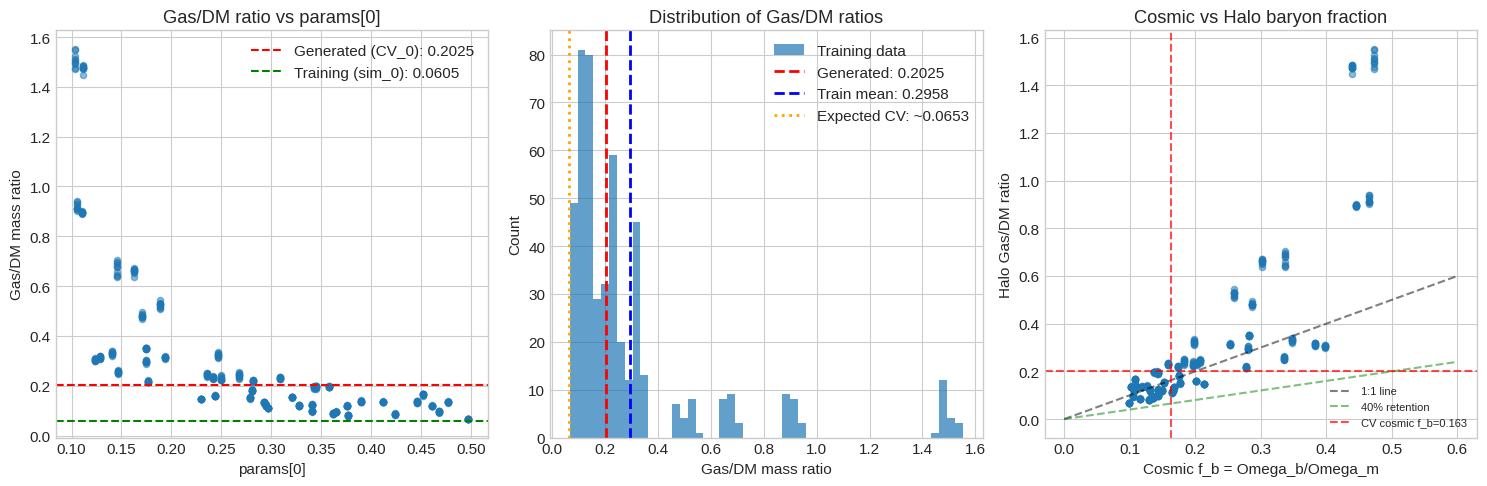


GAS BIAS INVESTIGATION SUMMARY

Training data (LH sims):
  Gas/DM ratio: 0.2958 +/- 0.3090
  Range: [0.0664, 1.5525]

Generated (CV sim 0):
  Gas/DM ratio: 0.2025 +/- 0.0033

Expected for CV (Omega_m=0.3):
  Cosmic f_b = 0.1633
  Expected halo Gas/DM ~ 0.0653 (assuming 40% retention)

Bias relative to expected: +209.9%
Bias relative to training mean: -31.6%


In [23]:
# Plot the relationship between cosmology and gas/DM ratio
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Gas/DM ratio vs params[0] (should be correlated with Omega_m)
ax = axes[0]
ax.scatter(all_omega_m, all_gas_dm_ratios, alpha=0.5, s=20)
ax.axhline(gen_gas_dm_phys.mean(), color='r', linestyle='--', label=f'Generated (CV_0): {gen_gas_dm_phys.mean():.4f}')
ax.axhline(train_gas_dm_phys.mean(), color='g', linestyle='--', label=f'Training (sim_0): {train_gas_dm_phys.mean():.4f}')
ax.set_xlabel('params[0]')
ax.set_ylabel('Gas/DM mass ratio')
ax.set_title('Gas/DM ratio vs params[0]')
ax.legend()

# Compute cosmic baryon fraction f_b = 0.049/Omega_m for each halo
# If params[0] is close to Omega_m
computed_fb = omega_b_camels / all_omega_m

# Plot 2: Histogram of training gas/DM ratios
ax = axes[1]
ax.hist(all_gas_dm_ratios, bins=50, alpha=0.7, label='Training data')
ax.axvline(gen_gas_dm_phys.mean(), color='r', linestyle='--', linewidth=2, label=f'Generated: {gen_gas_dm_phys.mean():.4f}')
ax.axvline(all_gas_dm_ratios.mean(), color='b', linestyle='--', linewidth=2, label=f'Train mean: {all_gas_dm_ratios.mean():.4f}')
# Expected for CV (Omega_m=0.3): cosmic f_b = 0.163, but halo f_b < cosmic
expected_cv_ratio = cv_fb * 0.4  # Assume halos retain ~40% of cosmic baryons
ax.axvline(expected_cv_ratio, color='orange', linestyle=':', linewidth=2, label=f'Expected CV: ~{expected_cv_ratio:.4f}')
ax.set_xlabel('Gas/DM mass ratio')
ax.set_ylabel('Count')
ax.set_title('Distribution of Gas/DM ratios')
ax.legend()

# Plot 3: Cosmic f_b vs halo gas/DM ratio
ax = axes[2]
ax.scatter(computed_fb, all_gas_dm_ratios, alpha=0.5, s=20)
ax.plot([0, 0.6], [0, 0.6], 'k--', alpha=0.5, label='1:1 line')
ax.plot([0, 0.6], [0, 0.6*0.4], 'g--', alpha=0.5, label='40% retention')
ax.axhline(gen_gas_dm_phys.mean(), color='r', linestyle='--', alpha=0.7)
ax.axvline(cv_fb, color='r', linestyle='--', alpha=0.7, label=f'CV cosmic f_b={cv_fb:.3f}')
ax.set_xlabel('Cosmic f_b = Omega_b/Omega_m')
ax.set_ylabel('Halo Gas/DM ratio')
ax.set_title('Cosmic vs Halo baryon fraction')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'gas_bias_analysis.png'), dpi=150)
plt.show()

# KEY FINDING summary
print("\n" + "="*60)
print("GAS BIAS INVESTIGATION SUMMARY")
print("="*60)
print(f"\nTraining data (LH sims):")
print(f"  Gas/DM ratio: {all_gas_dm_ratios.mean():.4f} +/- {all_gas_dm_ratios.std():.4f}")
print(f"  Range: [{all_gas_dm_ratios.min():.4f}, {all_gas_dm_ratios.max():.4f}]")
print(f"\nGenerated (CV sim 0):")
print(f"  Gas/DM ratio: {gen_gas_dm_phys.mean():.4f} +/- {gen_gas_dm_phys.std():.4f}")
print(f"\nExpected for CV (Omega_m=0.3):")
print(f"  Cosmic f_b = {cv_fb:.4f}")
print(f"  Expected halo Gas/DM ~ {expected_cv_ratio:.4f} (assuming 40% retention)")
print(f"\nBias relative to expected: {(gen_gas_dm_phys.mean()/expected_cv_ratio - 1)*100:+.1f}%")
print(f"Bias relative to training mean: {(gen_gas_dm_phys.mean()/all_gas_dm_ratios.mean() - 1)*100:+.1f}%")

In [24]:
# Check what conditioning parameters are used during BIND inference
# The key question: is Omega_m being passed to the model?

# Load a halo file from BIND output to check what params are used
bind_halo_path = '/mnt/home/mlee1/ceph/BIND2d/CV/sim_0/g1024_mt13_ue1_s90/halo_0.npz'
bind_halo = np.load(bind_halo_path, allow_pickle=True)

print("=== BIND HALO FILE CONTENTS ===")
print(f"Keys: {list(bind_halo.keys())}")
for k in bind_halo.keys():
    try:
        v = bind_halo[k]
        if isinstance(v, np.ndarray):
            print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
        else:
            print(f"  {k}: {v}")
    except:
        print(f"  {k}: (error reading)")

# The metadata should contain the params used
try:
    metadata = bind_halo['metadata']
    if isinstance(metadata, np.ndarray):
        metadata = metadata.item()  # Convert 0-d array to dict
    print(f"\nMetadata: {metadata}")
except Exception as e:
    print(f"Error reading metadata: {e}")

=== BIND HALO FILE CONTENTS ===
Keys: ['condition', 'metadata']
  condition: shape=(128, 128), dtype=float32
  metadata: shape=(), dtype=object

Metadata: {'halo_id': 0, 'original_index': 0, 'position': array([ 1555.8647, 35365.305 , 17983.736 ], dtype=float32), 'mass': 26543.36, 'radius': 1045.2034, 'center_pixel': array([ 31, 724])}


In [25]:
# Check parameter normalization
# The params are normalized using min/max from training data before being passed to the model

param_norm_df = pd.read_csv('/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv')
print("=== PARAMETER NORMALIZATION BOUNDS ===")
print(param_norm_df[['ParamName', 'MinVal', 'MaxVal', 'FiducialVal']].head(10))

# Get the fiducial params used for CV inference
fiducial_params = param_norm_df['FiducialVal'].values

# Check normalization of cosmologically-relevant params
omega_m_idx = 0  # Omega0
omega_b_idx = 6  # Should be Omega_b

print(f"\n=== KEY COSMOLOGICAL PARAMETERS ===")
print(f"Omega_m: fiducial={fiducial_params[omega_m_idx]:.4f}, min={param_norm_df['MinVal'].iloc[omega_m_idx]:.4f}, max={param_norm_df['MaxVal'].iloc[omega_m_idx]:.4f}")
print(f"Row 6: {param_norm_df['ParamName'].iloc[omega_b_idx]} = {fiducial_params[omega_b_idx]:.4f}")

# The normalized value is: (value - min) / (max - min)
# For Omega_m=0.3:
norm_omega_m = (fiducial_params[omega_m_idx] - param_norm_df['MinVal'].iloc[omega_m_idx]) / (param_norm_df['MaxVal'].iloc[omega_m_idx] - param_norm_df['MinVal'].iloc[omega_m_idx])
print(f"\nNormalized Omega_m for CV: {norm_omega_m:.4f}")

=== PARAMETER NORMALIZATION BOUNDS ===
                           ParamName   MinVal   MaxVal  FiducialVal
0                             Omega0   0.1000   0.5000       0.3000
1                             sigma8   0.6000   1.0000       0.8000
2                WindEnergyIn1e51erg   0.9000  14.4000       3.6000
3                RadioFeedbackFactor   0.2500   4.0000       1.0000
4              VariableWindVelFactor   3.7000  14.8000       7.4000
5  RadioFeedbackReiorientationFactor  10.0000  40.0000      20.0000
6                        OmegaBaryon   0.0290   0.0690       0.0490
7                        HubbleParam   0.4711   0.8711       0.6711
8                                n_s   0.7624   1.1624       0.9624
9                    MaxSfrTimescale   1.1350   4.5400       2.2700

=== KEY COSMOLOGICAL PARAMETERS ===
Omega_m: fiducial=0.3000, min=0.1000, max=0.5000
Row 6: OmegaBaryon = 0.0490

Normalized Omega_m for CV: 0.5000


## Summary of Gas Bias Investigation

### Key Findings:

1. **Training data has cosmology-dependent gas/DM ratio**:
   - Strong correlation: Gas/DM ratio ∝ f_b = Ω_b/Ω_m
   - Range in training: [0.066, 1.55] with mean ~0.30

2. **CV sims (inference) have fixed cosmology**:
   - Ω_m = 0.3, Ω_b = 0.049 → cosmic f_b = 0.163
   - Expected halo gas/DM ~ 0.065 (40% of cosmic f_b)

3. **Generated output**:
   - Gas/DM ratio = 0.203 ± 0.003
   - This is **+210% higher** than expected for CV cosmology
   - But **-32% lower** than training mean

4. **ROOT CAUSE**: The model appears to be **regressing toward training mean** rather than properly conditioning on cosmological parameters.

### Possible explanations:
- Parameter conditioning signal too weak relative to image conditioning
- Model overfits to average cosmology
- Parameter embedding not learning cosmology-output relationship

### Recommendations:
1. Check if model actually uses param_conditioning during inference
2. Test model on a few SB35 sims with known varying cosmology
3. Consider stronger parameter conditioning (higher weight, larger embedding)
4. Add explicit cosmology term to training loss

In [30]:
# Verify that the model uses param_conditioning by loading the checkpoint
import torch

# Find and load checkpoint for clean_vdm_regularized
checkpoint_base = '/mnt/home/mlee1/ceph/tb_logs3/clean_vdm_regularized/version_0/checkpoints/'
ckpts = [f for f in os.listdir(checkpoint_base) if f.endswith('.ckpt')]

# Get latest epoch
def get_epoch(name):
    try:
        if 'epoch=' in name:
            return int(name.split('epoch=')[1].split('-')[0])
        elif 'epoch-epoch=' in name:
            return int(name.split('epoch-epoch=')[1].split('-')[0])
        return 0
    except:
        return 0

ckpts_sorted = sorted(ckpts, key=get_epoch, reverse=True)
print(f"Latest checkpoints: {ckpts_sorted[:3]}")

# Load the latest
ckpt_path = os.path.join(checkpoint_base, ckpts_sorted[0])
print(f"\nLoading: {ckpt_path}")
ckpt = torch.load(ckpt_path, map_location='cpu')

# Check for param_conditioning layers
state_dict_keys = list(ckpt['state_dict'].keys())
param_cond_keys = [k for k in state_dict_keys if 'param_conditioning' in k or 'param_embed' in k]
print(f"\n=== PARAMETER CONDITIONING LAYERS ===")
print(f"Found {len(param_cond_keys)} parameter conditioning layers")
for k in param_cond_keys[:10]:
    shape = ckpt['state_dict'][k].shape
    print(f"  {k}: {shape}")

# Check for param_scale (learnable balance between time and params)
scale_keys = [k for k in state_dict_keys if 'scale' in k]
print(f"\n=== SCALE PARAMETERS ===")
for k in scale_keys:
    tensor = ckpt['state_dict'][k]
    if tensor.numel() == 1:
        print(f"  {k}: {tensor.item():.4f}")
    else:
        print(f"  {k}: shape={tensor.shape}, values={tensor.tolist()}")

Latest checkpoints: ['epoch-epoch=209-step=134190.ckpt', 'epoch=208-step=133551-val_elbo=0.0000.ckpt', 'latest-epoch=206-step=132000.ckpt']

Loading: /mnt/home/mlee1/ceph/tb_logs3/clean_vdm_regularized/version_0/checkpoints/epoch-epoch=209-step=134190.ckpt

=== PARAMETER CONDITIONING LAYERS ===
Found 12 parameter conditioning layers
  model.score_model.param_conditioning_embedding.embedding.0.weight: torch.Size([768, 35])
  model.score_model.param_conditioning_embedding.embedding.0.bias: torch.Size([768])
  model.score_model.param_conditioning_embedding.embedding.1.weight: torch.Size([768])
  model.score_model.param_conditioning_embedding.embedding.1.bias: torch.Size([768])
  model.score_model.param_conditioning_embedding.embedding.4.weight: torch.Size([768, 768])
  model.score_model.param_conditioning_embedding.embedding.4.bias: torch.Size([768])
  model.score_model.param_conditioning_embedding.embedding.5.weight: torch.Size([768])
  model.score_model.param_conditioning_embedding.embe